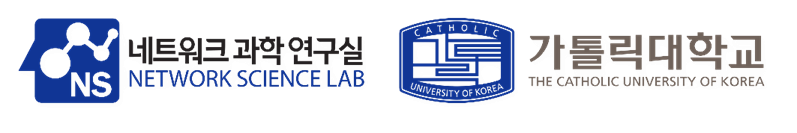

# 🎓 Graph Node Similarity and Proximity Metrics

Welcome! In this pedagogical notebook, we will explore the fundamental **heuristic metrics** used to evaluate the similarity and structural proximity between nodes in a graph. These traditional metrics are essential for understanding local graph structures and serve as the foundational intuition behind modern **Link Prediction** algorithms and **Graph Neural Networks (GNNs)**.

### 📚 Topics Covered:
1. **Graph Distance** (Shortest Path)
2. **Common Neighbors**
3. **Jaccard’s Coefficient**
4. **Adamic-Adar Index**
5. **Preferential Attachment**
6. **SimRank Similarity**

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# 🎨 Configure plotting aesthetics
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 100

def plot_graph(G, title="Graph Visualization", node_color='#A0CBE2', layout_seed=42):
    """
    A reusable helper function to draw beautiful graph visualizations.
    """
    plt.figure(figsize=(7, 5))
    # Use a fixed seed for spring_layout to ensure consistent visual results
    pos = nx.spring_layout(G, seed=layout_seed)
    
    nx.draw(
        G, pos, 
        with_labels=True, 
        node_color=node_color, 
        node_size=900, 
        edge_color='#888888', 
        width=1.5,
        font_size=12,
        font_weight='bold',
        edgecolors='#444444' # Node border
    )
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.show()

---
## 1. Graph Distance (Shortest Path)

The most intuitive measure of proximity is the shortest path distance between two nodes. The smaller the distance, the more "proximal" or closely related the nodes are considered to be.

* **Formula**: $ d(u, v) $ is the minimum number of edges connecting node $u$ and node $v$.

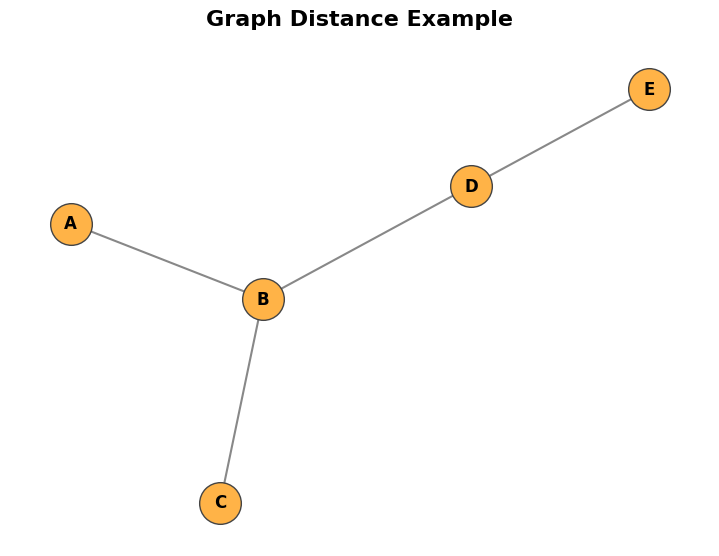

,Node Pair,Shortest Path Distance
0,"(A, C)",2
1,"(C, D)",2
2,"(A, E)",3


In [2]:
# Instantiate a simple graph for distance calculation
G_dist = nx.Graph()
edges_dist = [("A", "B"), ("B", "C"), ("B", "D"), ("D", "E")]
G_dist.add_edges_from(edges_dist)

# Visualize it
plot_graph(G_dist, title="Graph Distance Example", node_color='#FFB347')

# Calculate shortest path distances
distances = {
    ("A", "C"): nx.shortest_path_length(G_dist, source='A', target='C'),
    ("C", "D"): nx.shortest_path_length(G_dist, source='C', target='D'),
    ("A", "E"): nx.shortest_path_length(G_dist, source='A', target='E'),
}

# Display results in a clean DataFrame
df_distances = pd.DataFrame(list(distances.items()), columns=['Node Pair', 'Shortest Path Distance'])
display(df_distances)

---
## 2. Setting up a Complex Graph

For the remaining similarity metrics (Sections 3 through 7), we will use a more complex undirected graph. Many similarity metrics fundamentally rely on the concept of a **node's neighborhood**. 

> Let $N(u)$ be the set of direct neighbors of node $u$.

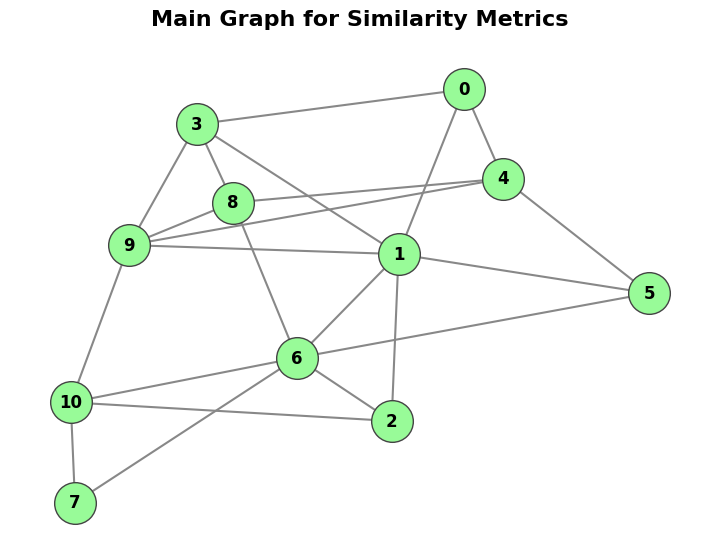

In [3]:
# Instantiate the main graph
G = nx.Graph()

# Define edges to create a complex graph structure with interesting neighborhoods
edges = [(0, 1), (1, 2), (0, 3), (1, 3), (0, 4), (1, 5), (4, 5), (1, 6), 
         (2, 6), (5, 6), (6, 7), (3, 8), (4, 8), (6, 8), (3, 9), (4, 9), 
         (1, 9), (8, 9), (2, 10), (6, 10), (7, 10), (9, 10)]

G.add_edges_from(edges)

# Visualize the main graph
plot_graph(G, title="Main Graph for Similarity Metrics", node_color='#98FB98', layout_seed=121)

# Let's define specific node pairs that we will compare throughout the next sections
target_pairs = [(6, 9), (1, 3), (3, 9)]

---
## 3. Common Neighbors

Two nodes are more likely to be connected or related if they share many common friends (neighbors).

* **Formula**: $ CN(u, v) = |N(u) \cap N(v)| $
* **Intuition**: Absolute count of shared neighbors.

In [4]:
# Calculate common neighbors for a specific pair, e.g., nodes 6 and 9
node_u, node_v = 6, 9
cn_list = sorted(nx.common_neighbors(G, node_u, node_v))

print(f"Nodes {node_u} and {node_v} share {len(cn_list)} common neighbor(s).")
print(f"The common neighbors are: {cn_list}")

Nodes 6 and 9 share 3 common neighbor(s).
The common neighbors are: [1, 8, 10]


---
## 4. Jaccard’s Coefficient

A normalized version of Common Neighbors. It penalizes nodes directly that simply have many edges (large degrees). If node $A$ is a celebrity with 1M friends, sharing 1 friend with them isn't as meaningful as sharing a friend with an introvert who only has 2 friends.

* **Formula**: $ J(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|} $
* **Range**: [0.0, 1.0]

In [5]:
# Calculate Jaccard coefficients for our target pairs
jaccard_preds = nx.jaccard_coefficient(G, target_pairs)

results = []
for u, v, p in jaccard_preds:
    results.append({"Node u": u, "Node v": v, "Jaccard Coefficient": round(p, 4)})

display(pd.DataFrame(results))

,Node u,Node v,Jaccard Coefficient
0,6,9,0.3750
1,1,3,0.2500
2,3,9,0.2857


---
## 5. Adamic-Adar Index

Similar to Common Neighbors, but it weights the common neighbors by their degree. A shared neighbor with a *small* degree provides more evidence of a strong relationship than a shared neighbor with a *large* degree (who is connected to everyone anyway).

* **Formula**: $ A(u, v) = \sum_{w \in N(u) \cap N(v)} \frac{1}{\log |N(w)|} $

In [6]:
# Calculate Adamic-Adar indices
aa_preds = nx.adamic_adar_index(G, target_pairs)

results = []
for u, v, p in aa_preds:
    results.append({"Node u": u, "Node v": v, "Adamic-Adar Index": round(p, 4)})

display(pd.DataFrame(results))

,Node u,Node v,Adamic-Adar Index
0,6,9,2.0008
1,1,3,1.5316
2,3,9,1.2795


---
## 6. Preferential Attachment

Based on the premise that "the rich get richer". Nodes with high degrees are more likely to form new connections. It does not look at *shared* neighbors, only the total degrees of the two nodes.

* **Formula**: $ PA(u, v) = |N(u)| \times |N(v)| $

In [7]:
# Calculate Preferential Attachment scores
pa_preds = nx.preferential_attachment(G, target_pairs)

results = []
for u, v, p in pa_preds:
    results.append({"Node u": u, "Node v": v, "Preferential Attachment": p})

display(pd.DataFrame(results))

,Node u,Node v,Preferential Attachment
0,6,9,30
1,1,3,24
2,3,9,20


---
## 7. SimRank Similarity

SimRank relies on a recursive definition: *"two objects are similar if they are referenced by similar objects."* It essentially computes the expected number of steps for two random surfers, starting at nodes $u$ and $v$, to meet at the same node.

* **Formula**: $ s(u, v) = C \frac{\sum_{x \in N(u)}\sum_{y \in N(v)} s(x, y)}{|N(u)||N(v)|} $
(where $C$ is a decay factor, typically 0.8 or 0.9)

In [8]:
source, target = 6, 9

# Calculate SimRank similarity between source and target
# Note: SimRank is computationally expensive for large graphs
simrank_sim = nx.simrank_similarity(G, source, target)

print(f"The SimRank similarity between nodes {source} and {target} is: {simrank_sim:.4f}")

The SimRank similarity between nodes 6 and 9 is: 0.4283
